# Data cleaning and Processing for Mulit-building clustering and benchmarking

In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()

Saving New York Local Law 84 Benchmarking(in).csv to New York Local Law 84 Benchmarking(in).csv


In [ ]:
import pandas as pd

file_name = "New York Local Law 84 Benchmarking(in).csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Shape: (135735, 32)


,id,year,zip_code,city,state,climate,building_class,facility_type,floor_area,year_built,...,window_glass_type,energy_star_label,energy_star_rating,leed_score,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int,data_source
0,1000057501,2011,10004,New York,NY,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970,...,Unknown,Unknown,77,Unknown,44.81111622,24.50249502,69.31361123,170.1098989,5.564099031,New York LL84 Benchmarking
1,1000057501,2013,10004,New York,NY,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970,...,Unknown,Unknown,73,Unknown,42.41234363,44.9340036,87.29877988,187.0193791,6.826763138,New York LL84 Benchmarking
2,1000057501,2014,10004,New York,NY,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970,...,Unknown,Unknown,77,Unknown,47.31770393,62.31964581,109.5780011,216.3070168,7.791479385,New York LL84 Benchmarking
3,1000057501,2015,10004,New York,NY,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970,...,Unknown,Unknown,71,Unknown,46.8349121,83.83871968,130.6858659,236.9933717,8.804044613,New York LL84 Benchmarking
4,1000057501,2016,10004,New York,NY,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970,...,Unknown,Unknown,77,Unknown,44.60765924,79.37127235,124.0053985,224.2954655,8.199263228,New York LL84 Benchmarking


In [ ]:
import numpy as np

print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (135735, 32)
Number of rows: 135735
Number of columns: 32


In [ ]:
import pandas as pd
import numpy as np

# Make a copy for analysis
df_analysis = df.copy()

# Replace common missing-value labels with NaN
missing_labels = ["Unknown", "unknown", "UNKNOWN", "", " ", "NA", "N/A", "nan", "None"]

df_analysis = df_analysis.replace(missing_labels, np.nan)

# feature summary
feature_summary = pd.DataFrame({
    "Feature Name": df_analysis.columns,
    "Data Type": df_analysis.dtypes.values,
    "Non-Null Count": df_analysis.notnull().sum().values,
    "Missing Count": df_analysis.isnull().sum().values,
    "Missing (%)": (df_analysis.isnull().sum().values / len(df_analysis)) * 100,
    "Unique Values": df_analysis.nunique(dropna=True).values
})

feature_summary = feature_summary.sort_values(by="Missing (%)", ascending=False)

display(feature_summary)

/tmp/ipykernel_1146/1909464019.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_analysis = df_analysis.replace(missing_labels, np.nan)


,Feature Name,Data Type,Non-Null Count,Missing Count,Missing (%),Unique Values
15,heating,float64,0,135735,100.000000,0
13,lighting,float64,0,135735,100.000000,0
14,air_flow_control,float64,0,135735,100.000000,0
22,window_glass_type,float64,0,135735,100.000000,0
20,roof_ceiling,float64,0,135735,100.000000,0
18,wall_type,float64,0,135735,100.000000,0
17,cooling,float64,0,135735,100.000000,0
16,heating_fuel,float64,0,135735,100.000000,0
25,leed_score,float64,0,135735,100.000000,0
23,energy_star_label,float64,0,135735,100.000000,0


In [ ]:
'''
in the code above i found out that many numrical values are treated as object so i repeated the code after converting the type so i can actually get the meaning of the number and see what is missing
'''

In [ ]:
import pandas as pd
import numpy as np

# Start fresh from original dataset
df_clean = df.copy()

# Replace missing labels
missing_labels = ["Unknown", "unknown", "UNKNOWN", "", " ", "NA", "N/A", "nan", "None"]
df_clean = df_clean.replace(missing_labels, np.nan)

# S Define columns by meaning, not only by dtype

# IDs / location labels: keep as object, do not convert for clustering
identifier_cols = ["id", "zip_code"]

# True categorical columns
categorical_cols = [
    "city",
    "state",
    "climate",
    "building_class",
    "facility_type",
    "wall_insulation_r_value",
    "data_source"
]

# these are the numeric columns that are incorrectly stored as object
numeric_cols_to_convert = [
    "year_built",
    "number_of_people",
    "occupant_density",
    "operating_hours",
    "energy_star_rating",
    "electric_eui",
    "fuel_eui",
    "site_eui",
    "source_eui",
    "ghg_emissions_int"
]

#  Convert only meaningful numeric columns
for col in numeric_cols_to_convert:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")


for col in identifier_cols + categorical_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype("object")

# Create summary after proper conversion
feature_summary_after_conversion = pd.DataFrame({
    "Feature Name": df_clean.columns,
    "Data Type After Conversion": df_clean.dtypes.values,
    "Non-Null Count": df_clean.notnull().sum().values,
    "Missing Count": df_clean.isnull().sum().values,
    "Missing (%)": (df_clean.isnull().sum().values / len(df_clean)) * 100,
    "Unique Values": df_clean.nunique(dropna=True).values
})

feature_summary_after_conversion = feature_summary_after_conversion.sort_values(
    by="Missing (%)",
    ascending=False
)

display(feature_summary_after_conversion)

/tmp/ipykernel_1146/2719653761.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean = df_clean.replace(missing_labels, np.nan)


,Feature Name,Data Type After Conversion,Non-Null Count,Missing Count,Missing (%),Unique Values
15,heating,float64,0,135735,100.000000,0
13,lighting,float64,0,135735,100.000000,0
14,air_flow_control,float64,0,135735,100.000000,0
22,window_glass_type,float64,0,135735,100.000000,0
20,roof_ceiling,float64,0,135735,100.000000,0
18,wall_type,float64,0,135735,100.000000,0
17,cooling,float64,0,135735,100.000000,0
16,heating_fuel,float64,0,135735,100.000000,0
25,leed_score,float64,0,135735,100.000000,0
23,energy_star_label,float64,0,135735,100.000000,0


# Drop mssing data that are 100% or 80 missing

In [ ]:
cols_to_drop = [
    "heating", "lighting", "air_flow_control", "window_glass_type",
    "roof_ceiling", "wall_type", "cooling", "heating_fuel",
    "leed_score", "energy_star_label", "window_glass_layers",
    "operating_hours", "occupant_density", "number_of_people",
    "wall_insulation_r_value", "data_source"
]

df_clean = df_clean.drop(columns=cols_to_drop)

In [ ]:

print("Current columns:")
print(df_clean.columns.tolist())

print("\nCurrent shape:", df_clean.shape)

Current columns:
['id', 'year', 'zip_code', 'city', 'state', 'climate', 'building_class', 'facility_type', 'floor_area', 'year_built', 'energy_star_rating', 'electric_eui', 'fuel_eui', 'site_eui', 'source_eui', 'ghg_emissions_int']

Current shape: (135735, 16)


In [ ]:
non_feature_cols = ["id", "zip_code", "city", "state"]

df_model = df_clean.drop(columns=non_feature_cols)

In [ ]:
print("Columns in df_model:")
print(df_model.columns.tolist())

print("\nShape:", df_model.shape)

display(df_model.head())

Columns in df_model:
['year', 'climate', 'building_class', 'facility_type', 'floor_area', 'year_built', 'energy_star_rating', 'electric_eui', 'fuel_eui', 'site_eui', 'source_eui', 'ghg_emissions_int']

Shape: (135735, 12)


,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263


# Handle rest of  the missing data

In [ ]:
print(df_model.isnull().sum())
# this shows how many data are missing for each feature

year                      0
climate                   0
building_class            0
facility_type             0
floor_area                0
year_built              554
energy_star_rating    27671
electric_eui           6406
fuel_eui              15825
site_eui               9600
source_eui             7359
ghg_emissions_int      1875
dtype: int64


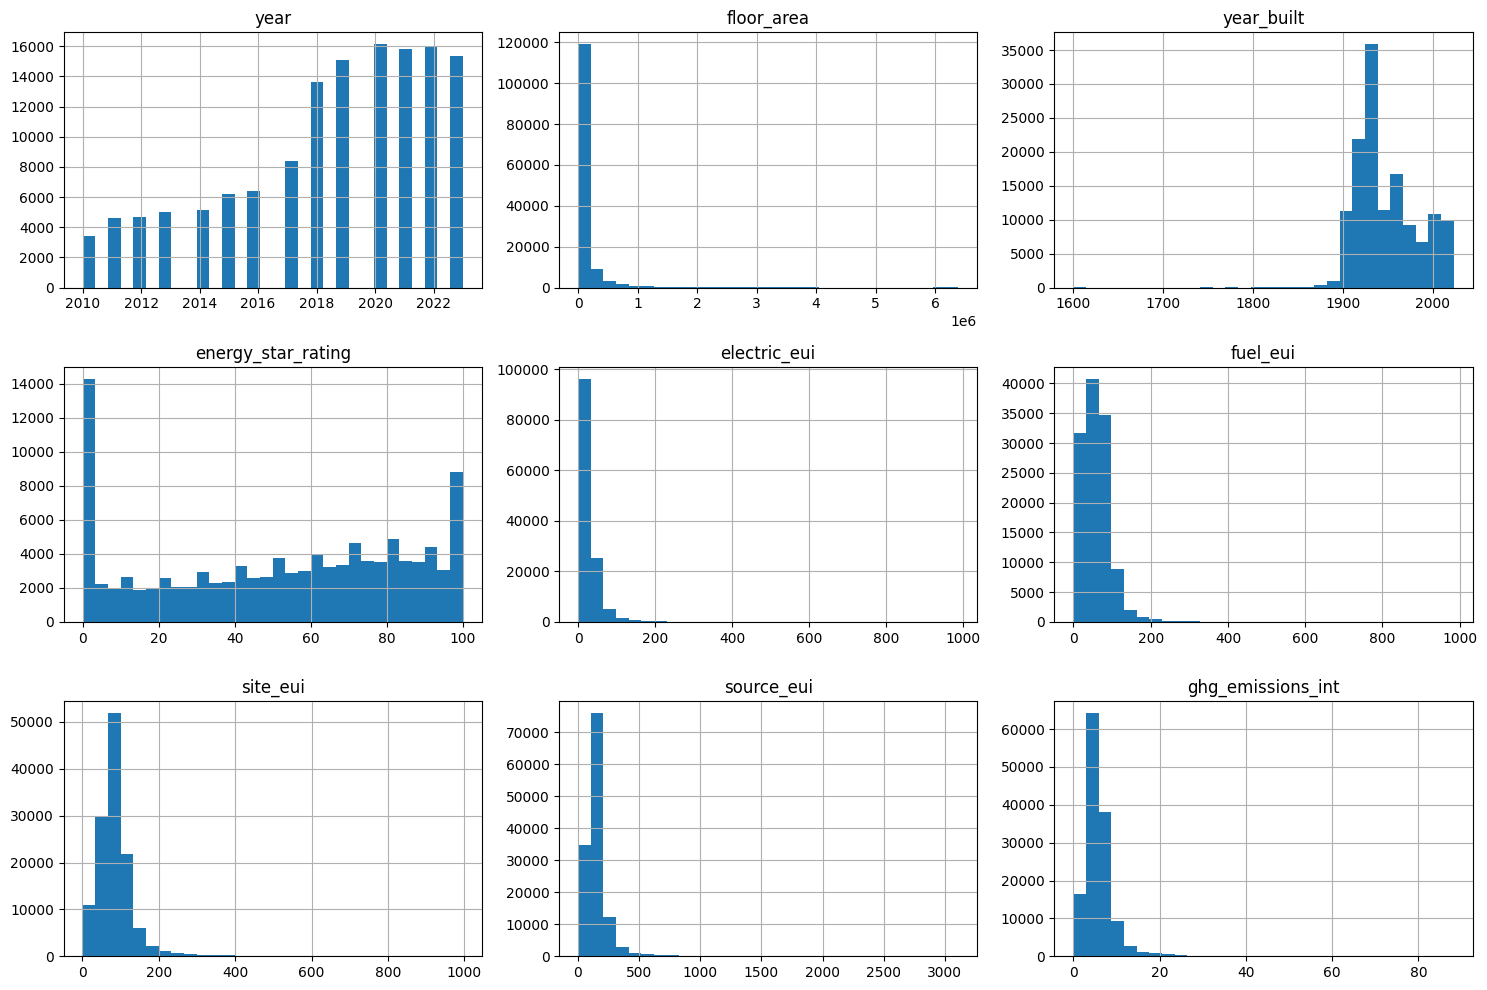

In [ ]:
import matplotlib.pyplot as plt
# this is to look at the data distrbution to decide what is the best way to replace missing data
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

df_model[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())
#used median as its softer with skewed data where as mid will be harsh
# Check missing values again
print(df_model.isnull().sum())

year                  0
climate               0
building_class        0
facility_type         0
floor_area            0
year_built            0
energy_star_rating    0
electric_eui          0
fuel_eui              0
site_eui              0
source_eui            0
ghg_emissions_int     0
dtype: int64


In [ ]:
df_model.head()

,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263


In [ ]:
# investugate and understand the categorial data
for col in ["climate", "building_class", "facility_type"]:
    print("\n" + "="*50)
    print(f"Column: {col}")
    print(f"Number of unique values: {df_model[col].nunique()}")
    print("Unique values:")
    print(df_model[col].unique())


Column: climate
Number of unique values: 3
Unique values:
['4A Mixed - Humid (Baltimore-MD)' '6A Cold - Humid (Burlington-VT)'
 '5A Cool - Humid (Chicago-IL)']

Column: building_class
Number of unique values: 2
Unique values:
['Commercial' 'Residential']

Column: facility_type
Number of unique values: 58
Unique values:
['Office - Uncategorized' 'Multifamily - Uncategorized' 'Lodging - Hotel'
 'Health Care - Inpatient' 'Education - College or university'
 'Public Safety - Fire or police station' 'Public Safety - Courthouse'
 'Lodging - Dormitory or fraternity/sorority'
 'Mixed Use - Commercial and Residential'
 'Health Care - Outpatient Clinic' 'Industrial'
 'Public Safety - Penitentiary' 'Commercial - Other'
 'Education - Other classroom' 'Retail - Uncategorized' 'Parking Garage'
 'Public Assembly - Library' 'Grocery store or food market'
 'Lodging - Other' 'Public Assembly - Drama theater'
 'Food Service - Restaurant or cafeteria' 'Education - Uncategorized'
 'Warehouse - Non-refrige

In [ ]:
df_model["facility_type"].value_counts().head(58)
# the biggest category

,count
facility_type,
Multifamily - Uncategorized,89124
Office - Uncategorized,16314
Education - Other classroom,4343
Lodging - Hotel,2477
Warehouse - Non-refrigerated,2225
Industrial,1831
Retail - Uncategorized,1257
Nursing Home,1193
Public Safety - Fire or police station,1173


# Encode categorial values

In [ ]:
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [ ]:
print("Shape:", df_encoded.shape)

Shape: (135735, 69)


In [ ]:
# Original numeric features
num_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Encoded categorical features
encoded_cols = [col for col in df_encoded.columns if col not in num_cols]

print("Numerical Features:")
print(num_cols)

print("\nEncoded Categorical Features:")
print(encoded_cols)

Numerical Features:
['year', 'floor_area', 'year_built', 'energy_star_rating', 'electric_eui', 'fuel_eui', 'site_eui', 'source_eui', 'ghg_emissions_int']

Encoded Categorical Features:
['climate_5A Cool - Humid (Chicago-IL)', 'climate_6A Cold - Humid (Burlington-VT)', 'building_class_Residential', 'facility_type_Commercial - Unknown', 'facility_type_Data Center', 'facility_type_Education - College or university', 'facility_type_Education - Other classroom', 'facility_type_Education - Preschool or daycare', 'facility_type_Education - Uncategorized', 'facility_type_Food Sales', 'facility_type_Food Service - Fast food', 'facility_type_Food Service - Other', 'facility_type_Food Service - Restaurant or cafeteria', 'facility_type_Food Service - Uncategorized', 'facility_type_Grocery store or food market', 'facility_type_Health Care - Inpatient', 'facility_type_Health Care - Outpatient Clinic', 'facility_type_Health Care - Outpatient Uncategorized', 'facility_type_Health Care - Uncategorized'

In [ ]:
print("Number of numerical features:", len(num_cols))
print("Number of encoded categorical features:", len(encoded_cols))
print("Total features:", df_encoded.shape[1])

Number of numerical features: 9
Number of encoded categorical features: 60
Total features: 69


In [ ]:
feature_summary = pd.DataFrame({
    "Feature Name": df_encoded.columns,
    "Data Type": df_encoded.dtypes.values,
    "Unique Values": df_encoded.nunique().values
})

display(feature_summary)

,Feature Name,Data Type,Unique Values
0,year,int64,14
1,floor_area,int64,13895
2,year_built,float64,186
3,energy_star_rating,float64,101
4,electric_eui,float64,129188
...,...,...,...
64,facility_type_Transportation Terminal,bool,2
65,facility_type_Warehouse - Distribution or Ship...,bool,2
66,facility_type_Warehouse - Non-refrigerated,bool,2
67,facility_type_Warehouse - Refrigerated,bool,2


In [ ]:
df_model

,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263
...,...,...,...,...,...,...,...,...,...,...,...,...
135730,2023,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,386608,1971.0,100.0,6.293587,2.619190,8.912778,22.512013,0.880851
135731,2018,4A Mixed - Humid (Baltimore-MD),Commercial,Warehouse - Self-storage,46350,2001.0,56.0,4.850811,8.493129,13.343940,24.149333,0.836453
135732,2019,4A Mixed - Humid (Baltimore-MD),Commercial,Warehouse - Self-storage,46350,2001.0,56.0,5.086519,8.284984,13.371504,24.670905,0.815498
135733,2020,4A Mixed - Humid (Baltimore-MD),Commercial,Warehouse - Self-storage,46350,2001.0,56.0,5.678458,5.638638,11.317096,23.750927,0.779530


# Scale data

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Make a safe copy
df_work = df_model.copy()

# 2. Fill missing numeric values only
continuous_cols = [
    "year",
    "floor_area",
    "year_built",
    "energy_star_rating",
    "electric_eui",
    "fuel_eui",
    "site_eui",
    "source_eui",
    "ghg_emissions_int"
]

for col in continuous_cols:
    df_work[col] = df_work[col].fillna(df_work[col].median())

# 3. One-hot encode categorical columns
df_encoded = pd.get_dummies(df_work, drop_first=True)

# 4. Identify dummy columns
dummy_cols = [col for col in df_encoded.columns if col not in continuous_cols]

# 5. Scale continuous columns only
scaler = StandardScaler()

df_scaled_cont = pd.DataFrame(
    scaler.fit_transform(df_encoded[continuous_cols]),
    columns=continuous_cols,
    index=df_encoded.index
)

# 6. Keep dummy columns as 0/1
df_final = pd.concat(
    [df_scaled_cont, df_encoded[dummy_cols].astype(int)],
    axis=1
)

# 7. Check final result
print("Final shape:", df_final.shape)
print("Missing values:", df_final.isnull().sum().sum())

display(df_final[continuous_cols].describe())
display(df_final[dummy_cols].head())

Final shape: (135735, 69)
Missing values: 0


,year,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
count,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05,1.357350e+05
mean,-8.413337e-15,1.800764e-17,2.031932e-15,6.281735e-18,-1.961995e-16,1.842642e-16,-2.717897e-16,-1.164215e-16,2.558760e-16
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00
min,-2.362957e+00,-5.384377e-01,-1.023873e+01,-1.792517e+00,-9.553281e-01,-1.454421e+00,-1.668606e+00,-1.430435e+00,-1.522268e+00
25%,-6.876159e-01,-3.856620e-01,-7.036562e-01,-7.040580e-01,-4.806857e-01,-5.767133e-01,-4.619676e-01,-4.348529e-01,-4.686187e-01
50%,1.500548e-01,-2.988117e-01,-3.505052e-01,1.122860e-01,-2.938036e-01,-2.662886e-02,-1.109094e-01,-1.940697e-01,-1.517434e-01
75%,7.085019e-01,-5.899117e-02,6.500892e-01,7.585583e-01,1.540597e-01,4.280724e-01,2.699393e-01,1.523050e-01,2.441665e-01
max,1.266949e+00,2.646715e+01,2.209839e+00,1.608917e+00,3.286732e+01,2.312289e+01,1.775927e+01,2.862980e+01,2.107024e+01


,climate_5A Cool - Humid (Chicago-IL),climate_6A Cold - Humid (Burlington-VT),building_class_Residential,facility_type_Commercial - Unknown,facility_type_Data Center,facility_type_Education - College or university,facility_type_Education - Other classroom,facility_type_Education - Preschool or daycare,facility_type_Education - Uncategorized,facility_type_Food Sales,...,facility_type_Service - Dry-cleaning or Laundry,facility_type_Service - Other service,facility_type_Service - Post office or postal center,facility_type_Service - Vehicle service/repair shop,facility_type_Single Family - Uncategorized,facility_type_Transportation Terminal,facility_type_Warehouse - Distribution or Shipping center,facility_type_Warehouse - Non-refrigerated,facility_type_Warehouse - Refrigerated,facility_type_Warehouse - Self-storage
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
#ensure ranges are correct mean has to be close to zero and std close to 1
print("Mean (approx):", np.mean(X_scaled))
print("Std (approx):", np.std(X_scaled))

Mean (approx): -9.592542962230548e-17
Std (approx): 0.9999999999999999


In [ ]:
print("Continuous columns scaled:")
display(df_final[continuous_cols].describe())

print("Dummy columns still 0/1:")
display(df_final[dummy_cols].head())

Continuous columns scaled:


,year,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
count,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000
mean,-0.114326,0.164055,0.097086,-0.022374,0.160850,0.010550,0.065230,0.115733,0.082167
std,0.667405,0.834116,0.632019,0.620290,0.793636,0.766635,0.792081,0.810445,0.801752
min,-2.000000,0.000000,-10.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,26.000000,2.000000,1.000000,32.000000,23.000000,17.000000,28.000000,21.000000


Dummy columns still 0/1:


,climate_5A Cool - Humid (Chicago-IL),climate_6A Cold - Humid (Burlington-VT),building_class_Residential,facility_type_Commercial - Unknown,facility_type_Data Center,facility_type_Education - College or university,facility_type_Education - Other classroom,facility_type_Education - Preschool or daycare,facility_type_Education - Uncategorized,facility_type_Food Sales,...,facility_type_Service - Dry-cleaning or Laundry,facility_type_Service - Other service,facility_type_Service - Post office or postal center,facility_type_Service - Vehicle service/repair shop,facility_type_Single Family - Uncategorized,facility_type_Transportation Terminal,facility_type_Warehouse - Distribution or Shipping center,facility_type_Warehouse - Non-refrigerated,facility_type_Warehouse - Refrigerated,facility_type_Warehouse - Self-storage
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_final = df_final.astype(int, errors='ignore')

In [ ]:
continuous_cols = [
    "year",
    "floor_area",
    "year_built",
    "energy_star_rating",
    "electric_eui",
    "fuel_eui",
    "site_eui",
    "source_eui",
    "ghg_emissions_int"
]

df_final[continuous_cols].describe()

,year,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
count,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000
mean,-0.114326,0.164055,0.097086,-0.022374,0.160850,0.010550,0.065230,0.115733,0.082167
std,0.667405,0.834116,0.632019,0.620290,0.793636,0.766635,0.792081,0.810445,0.801752
min,-2.000000,0.000000,-10.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,26.000000,2.000000,1.000000,32.000000,23.000000,17.000000,28.000000,21.000000


In [ ]:
dummy_cols = [col for col in df_final.columns if col not in continuous_cols]

df_final[dummy_cols].describe()

,climate_5A Cool - Humid (Chicago-IL),climate_6A Cold - Humid (Burlington-VT),building_class_Residential,facility_type_Commercial - Unknown,facility_type_Data Center,facility_type_Education - College or university,facility_type_Education - Other classroom,facility_type_Education - Preschool or daycare,facility_type_Education - Uncategorized,facility_type_Food Sales,...,facility_type_Service - Dry-cleaning or Laundry,facility_type_Service - Other service,facility_type_Service - Post office or postal center,facility_type_Service - Vehicle service/repair shop,facility_type_Single Family - Uncategorized,facility_type_Transportation Terminal,facility_type_Warehouse - Distribution or Shipping center,facility_type_Warehouse - Non-refrigerated,facility_type_Warehouse - Refrigerated,facility_type_Warehouse - Self-storage
count,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,...,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000,135735.000000
mean,0.000022,0.000022,0.664501,0.000029,0.002682,0.007515,0.031996,0.007301,0.000302,0.000457,...,0.000007,0.000523,0.000037,0.005776,0.000037,0.000354,0.004796,0.016392,0.001385,0.007176
std,0.004701,0.004701,0.472166,0.005428,0.051716,0.086361,0.175990,0.085134,0.017377,0.021367,...,0.002714,0.022865,0.006069,0.075780,0.006069,0.018802,0.069088,0.126979,0.037191,0.084406
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
#encoding  all the facilty types lead to inceraed dimentionality but its also sparse data now

# Dimentionality reduction

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(df_final)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

In [ ]:
for i, v in enumerate(cumulative_variance):
    print(f"{i+1} components → {v:.4f}")

1 components → 0.4006
2 components → 0.5521
3 components → 0.6780
4 components → 0.7737
5 components → 0.8636
6 components → 0.9213
7 components → 0.9537
8 components → 0.9643
9 components → 0.9717
10 components → 0.9775
11 components → 0.9804
12 components → 0.9821
13 components → 0.9837
14 components → 0.9850
15 components → 0.9863
16 components → 0.9875
17 components → 0.9884
18 components → 0.9893
19 components → 0.9901
20 components → 0.9909
21 components → 0.9916
22 components → 0.9923
23 components → 0.9930
24 components → 0.9937
25 components → 0.9943
26 components → 0.9948
27 components → 0.9954
28 components → 0.9959
29 components → 0.9963
30 components → 0.9967
31 components → 0.9971
32 components → 0.9973
33 components → 0.9976
34 components → 0.9979
35 components → 0.9981
36 components → 0.9983
37 components → 0.9985
38 components → 0.9987
39 components → 0.9989
40 components → 0.9991
41 components → 0.9992
42 components → 0.9993
43 components → 0.9994
44 components → 0.99

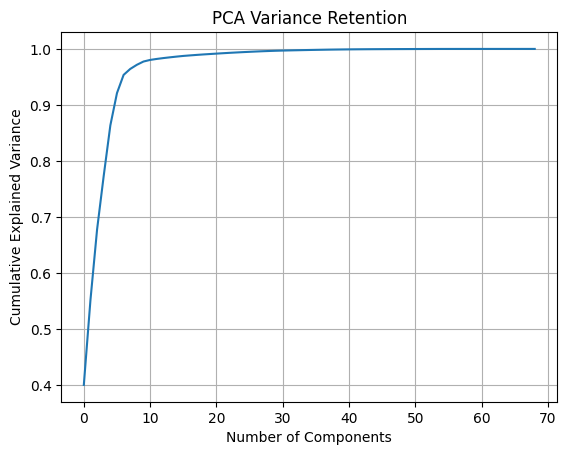

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Retention")
plt.grid()
plt.show()

In [ ]:
pca_final = PCA(n_components=0.97)  # keep 90% variance
X_reduced = pca_final.fit_transform(df_final)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (135735, 9)


In [ ]:
mp

A PCA threshold of 97% variance retention was selected to ensure that the majority of the dataset’s information is preserved while still reducing dimensionality. Lower thresholds for example 90% resulted in excessive compression and potential loss of important structure, particularly for categorical features.

In [ ]:
# 1. Clean dataset
df_model.to_csv("clean_data.csv", index=False)

# 2. Processed model-ready dataset
# numeric features scaled + categorical features encoded
df_final.to_csv("processed_data.csv", index=False)

# 3. PCA-reduced dataset
# compressed features used for clustering
df_pca = pd.DataFrame(
    X_reduced,
    columns=[f"PC{i+1}" for i in range(X_reduced.shape[1])]
)

df_pca.to_csv("pca_data.csv", index=False)

print("Saved files:")
print("clean_data.csv")
print("processed_data.csv")
print("pca_data.csv")

Saved files:
clean_data.csv
processed_data.csv
pca_data.csv


In [ ]:
global_benchmark = df_model[[
    "site_eui",
    "source_eui",
    "electric_eui",
    "fuel_eui",
    "ghg_emissions_int"
]].agg(["mean", "std"]).T

global_benchmark.columns = ["Mean", "Std"]
global_benchmark

,Mean,Std
site_eui,86.441508,51.196360
source_eui,149.274547,103.362958
electric_eui,27.886124,29.190209
fuel_eui,58.240144,40.043673
ghg_emissions_int,5.973116,3.900065


In [ ]:
facility_benchmark = df_model.groupby("facility_type")[[
    "site_eui",
    "source_eui",
    "electric_eui",
    "fuel_eui",
    "ghg_emissions_int"
]].agg(["mean", "std"])

In [ ]:
facility_benchmark.columns = [
    f"{metric}_{stat}" for metric, stat in facility_benchmark.columns
]

facility_benchmark = facility_benchmark.reset_index()
facility_benchmark

,facility_type,site_eui_mean,site_eui_std,source_eui_mean,source_eui_std,electric_eui_mean,electric_eui_std,fuel_eui_mean,fuel_eui_std,ghg_emissions_int_mean,ghg_emissions_int_std
0,Commercial - Other,124.043033,80.069291,243.057626,178.442896,53.012510,50.977485,69.364261,53.085186,9.032230,6.312462
1,Commercial - Unknown,29.557425,34.280938,61.714819,46.064174,16.991022,2.732043,0.000000,0.000000,2.073168,2.215879
2,Data Center,246.399254,125.525545,683.433422,354.505424,201.961539,113.845494,50.021186,67.213178,22.629691,10.900107
3,Education - College or university,96.149605,82.408046,197.803509,147.732453,45.490786,34.178691,46.936082,63.541677,7.329115,5.820924
4,Education - Other classroom,71.318655,32.623895,136.350037,69.920990,29.529973,20.222644,41.783923,24.675355,5.210463,2.899510
5,Education - Preschool or daycare,63.542095,40.403293,147.550448,78.924927,38.467579,21.388029,24.098007,30.877134,4.932433,3.077547
6,Education - Uncategorized,81.133088,41.824070,155.067525,52.257194,35.266166,12.226918,47.430385,39.863765,5.486630,2.480952
7,Food Sales,143.258630,80.726950,337.410137,184.342723,90.032255,54.426879,55.496740,56.434332,11.130142,5.862555
8,Food Service - Fast food,3.923971,NaN,12.321270,NaN,3.923971,NaN,0.000000,NaN,0.462469,NaN
9,Food Service - Other,91.087313,37.028606,176.751368,45.861506,38.808464,7.970894,52.278849,35.937803,6.822986,1.604524


In [ ]:
global_benchmark_rounded = global_benchmark.round(2)
global_benchmark_rounded

,Mean,Std
site_eui,86.44,51.20
source_eui,149.27,103.36
electric_eui,27.89,29.19
fuel_eui,58.24,40.04
ghg_emissions_int,5.97,3.90


In [ ]:

# BASELINE BENCHMARKING


energy_metrics = [
    "site_eui",
    "source_eui",
    "electric_eui",
    "fuel_eui",
    "ghg_emissions_int"
]

# 1. Global benchmark baseline
global_benchmark = df_model[energy_metrics].agg(["mean", "std"]).T
global_benchmark.columns = ["Mean", "Std"]
global_benchmark = global_benchmark.round(2)

display(global_benchmark)

# 2. Facility-type benchmark baseline
facility_benchmark = df_model.groupby("facility_type")[energy_metrics].agg(["mean", "std"])

# Flatten column names
facility_benchmark.columns = [
    f"{metric}_{stat}" for metric, stat in facility_benchmark.columns
]

facility_benchmark = facility_benchmark.reset_index()

# Add number of buildings per facility type
facility_counts = df_model["facility_type"].value_counts().reset_index()
facility_counts.columns = ["facility_type", "count"]

facility_benchmark = facility_benchmark.merge(facility_counts, on="facility_type")
facility_benchmark = facility_benchmark.sort_values(by="count", ascending=False)

facility_benchmark = facility_benchmark.round(2)

display(facility_benchmark)

# Save baseline tables
global_benchmark.to_csv("global_baseline.csv")
facility_benchmark.to_csv("facility_baseline.csv", index=False)

print("Baseline files saved:")
print("global_baseline.csv")
print("facility_baseline.csv")

,Mean,Std
site_eui,86.44,51.20
source_eui,149.27,103.36
electric_eui,27.89,29.19
fuel_eui,58.24,40.04
ghg_emissions_int,5.97,3.90


,facility_type,site_eui_mean,site_eui_std,source_eui_mean,source_eui_std,electric_eui_mean,electric_eui_std,fuel_eui_mean,fuel_eui_std,ghg_emissions_int_mean,ghg_emissions_int_std,count
24,Multifamily - Uncategorized,84.86,35.82,129.16,50.48,19.25,11.25,65.03,33.61,5.55,2.55,89124
28,Office - Uncategorized,77.69,42.43,175.52,99.70,44.31,28.77,36.50,27.57,6.17,3.54,16314
4,Education - Other classroom,71.32,32.62,136.35,69.92,29.53,20.22,41.78,24.68,5.21,2.90,4343
20,Lodging - Hotel,104.54,51.63,213.22,98.39,48.63,24.70,56.20,38.07,7.84,3.85,2477
55,Warehouse - Non-refrigerated,51.88,45.16,96.10,94.31,20.16,25.86,31.43,31.40,3.50,3.41,2225
17,Industrial,96.42,133.39,202.04,302.49,47.94,84.26,46.02,79.45,7.22,10.39,1831
46,Retail - Uncategorized,82.87,62.22,196.97,143.95,52.24,41.61,30.35,36.09,6.61,4.95,1257
25,Nursing Home,132.49,67.00,243.54,103.80,49.14,23.33,76.53,54.45,9.32,4.49,1193
41,Public Safety - Fire or police station,135.07,46.70,260.07,88.60,56.28,22.52,77.63,33.65,9.64,3.47,1173
23,Mixed Use - Commercial and Residential,100.90,76.10,214.05,151.21,52.35,42.92,48.63,54.08,7.82,5.86,1067


Baseline files saved:
global_baseline.csv
facility_baseline.csv
